In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from plot_utils import fast_plot

In [2]:
import os, sys
root_dir = os.path.abspath('..')

if root_dir not in sys.path:
    sys.path.append(root_dir)

In [6]:
data_path = root_dir + '/data'

In [35]:
file_path = data_path + '/trips.csv'
data = pd.read_csv(file_path)

In [36]:
data.head()

,date,value
0,2023-01-01,72.46
1,2023-01-02,91.04
2,2023-01-03,97.81
3,2023-01-04,89.57
4,2023-01-05,77.51


In [37]:
import numpy as np

def smape(y_pred, y_true):
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    if len(y_pred) != len(y_true):
        raise ValueError("Shapes mismatch")

    n = len(y_pred)
    if n == 0:
        return np.nan

    numerator = np.abs(y_pred - y_true)
    denominator = np.abs(y_pred) + np.abs(y_true)

    # чтобы избежать деления на ноль
    mask = denominator == 0
    denominator[mask] = 1

    res = (2.0 / n) * np.sum(numerator / denominator)
    return res


In [42]:
for i in range(1, 30):
    data[f'ma_{i}'] = data['value'].rolling(window=i).mean()
    # прогнозом на t+1 считаем ma на t
    df = data[[f'ma_{i}', 'value']].dropna()
    # сместим таргет так, чтобы индексы совпадали
    df['target'] = df['value'].shift(-1)
    df = df.dropna()

    metric = smape(df[f'ma_{i}'], df['target'])
    print(f"for {i} smape: {round(metric,2)*100}")


for 1 smape: 33.0
for 2 smape: 33.0
for 3 smape: 35.0
for 4 smape: 35.0
for 5 smape: 33.0
for 6 smape: 31.0
for 7 smape: 28.000000000000004
for 8 smape: 27.0
for 9 smape: 28.000000000000004
for 10 smape: 28.999999999999996
for 11 smape: 30.0
for 12 smape: 30.0
for 13 smape: 28.999999999999996
for 14 smape: 28.000000000000004
for 15 smape: 27.0
for 16 smape: 28.000000000000004
for 17 smape: 28.000000000000004
for 18 smape: 28.999999999999996
for 19 smape: 28.999999999999996
for 20 smape: 28.999999999999996
for 21 smape: 28.000000000000004
for 22 smape: 27.0
for 23 smape: 28.000000000000004
for 24 smape: 28.000000000000004
for 25 smape: 28.999999999999996
for 26 smape: 28.999999999999996
for 27 smape: 28.000000000000004
for 28 smape: 28.000000000000004
for 29 smape: 28.000000000000004


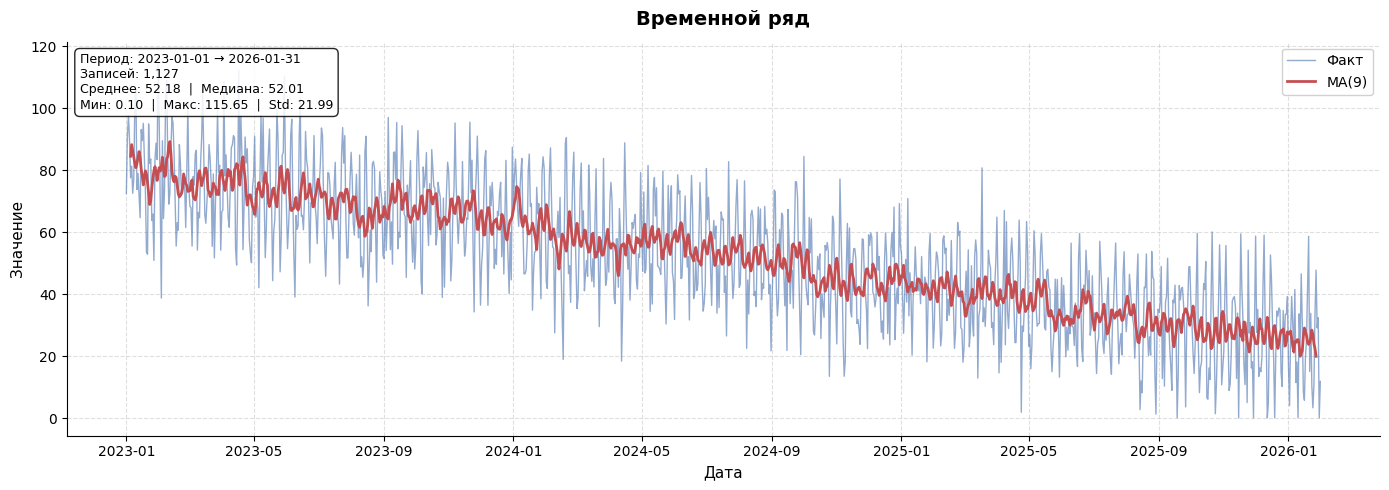

In [41]:
# В качестве бейзлайна берем MA с 8 точками:

fast_plot(data, ma_windows=[9])